# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 40   |  |
| :-------------|:-------------|
| Xin Qi Huang | 6345735|
| Aren Meghdadi| 6474349 |
| Lars Mulder  | 6546862 |
| Planning Groep: 40    | |
|---|---|
| Mijlpaal 1:  sanity check 1 en 2                | 12:00 |
| Mijlpaal 2:  sanity check 3                     | 12:30 |
| Mijlpaal 3:  synthese en evalutaie              | 14:30 |
| MIjlpaal 4:  simulatie en begin fabricge        |15:30|
| Mijlpaal 5:  sensor gemaakt en metingen gedaan  | 16:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 15:45-16:00 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="tudelftLogo.png" alt="schets student 1" width="400"/>

In [2]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt 

# constante
epsilon_0 = 8.85e-12
epsilon_r = 1

# capaciteit berekenen 
def vlakkeplaat(A, d, epsilon_r):
    return epsilon_0 * epsilon_r * A / d

# dikte om 50 pF te bereiken 
d = (epsilon_0 * epsilon_r * 0.01) / 50e-12
print(f'De dikte voor 50 pF moet zijn {d:.4f} m') 


De dikte voor 50 pF moet zijn 0.0018 m


In [3]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.
C = vlakkeplaat(0.01,1e-3,epsilon_r=3)
C_pf = C*1e12

print(f"Berekende verwachte capaciteit plaatcondensator groep 40 is {C_pf:.1f} pF")



Berekende verwachte capaciteit plaatcondensator groep 40 is 265.5 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](condensator.jpeg)
![scope meting 2](oscilloscoop.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 40| 265.5 pF |1.33 V | 1.04 V |206.9 pF |

De gemeten capaciteit is kleiner doordat we de parameters niet goed geschat hebben en de draden ook invloed hebben op de capaciteit(waar de berekening geen rekening mee houd). 

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](synthese_schets.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die het gewicht meet van bepaalde objecten door middel van variërende afstanden tussen de 2 platen. 

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

![uitgewerkte schets](sensorschets.jpeg)

natuurkundige afleiding van het verband tussen gewicht en capaciteit
![natuurkundige afleiding](afleiding.jpeg)

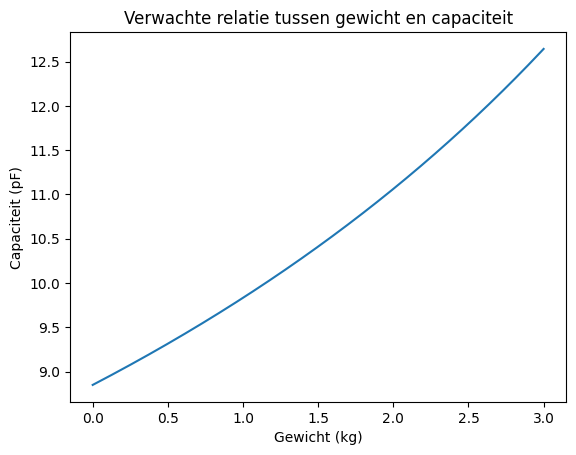

In [57]:
# geschatte parameters
epsilon_0 = 8.85e-12      # permittiviteit (lucht)
A = 0.01                  # plaatoppervlak (m^2)
d0 = 0.01                 # beginafstand zonder gewicht (m)
k = 0.001                 # indrukking per kg (m/kg)

# Gewicht (kg)
x = np.linspace(0, 3, 500)

# Nieuwe afstand tussen platen
d = d0 - k*x

# Capaciteit
C = (epsilon_0 * A / d)*1e12

# Plot
plt.plot(x, C)
plt.xlabel("Gewicht (kg)")
plt.ylabel("Capaciteit (pF)")
plt.title("Verwachte relatie tussen gewicht en capaciteit")
plt.show()

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minimale| 15 |160 |
| gemiddelde| 105 |1000 |
| maximale| 200 |2000|

## Opdracht 6: Foto's werkende opstelling.

![meting 1](werkende-opstelling1.jpeg)
![meting 2](werkende-opstelling2.jpeg)

## Opdracht 7: Plot de kalibratiegrafiek.

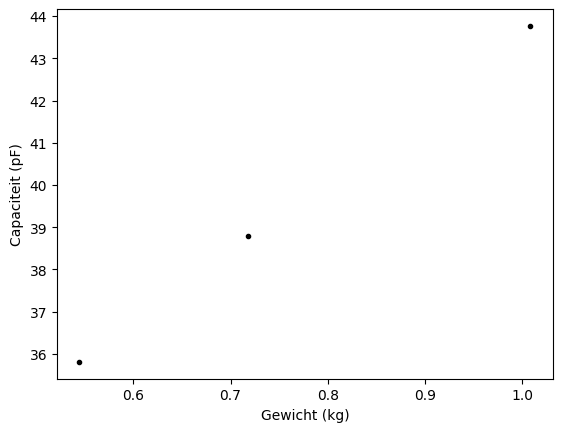

In [ ]:
# oscilloscoop metingen

# parameters
R_shunt = 1000  # Ohm
freq = 100000   # Hz
A_in = 8        # V

# data
amplitude = np.array([0.180, 0.220, 0.195])
capaciteit = (amplitude / (R_shunt * 2 * np.pi * freq * A_in)) * 1e12 # pF
gewicht = np.array([0.5446, 1.0083, 0.7181]) # kg

# plotten
plt.figure()
plt.xlabel('Gewicht (kg)')
plt.ylabel('Capaciteit (pF)')
plt.plot(gewicht, capaciteit, 'k.')
plt.show()

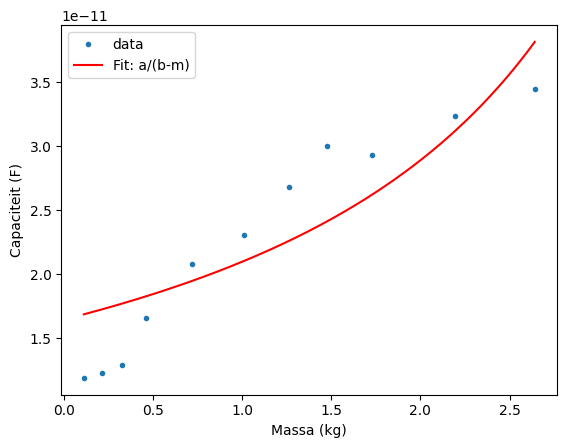

In [63]:
# data
capaciteitino = np.array([23.1, 20.8, 16.6, 29.3, 32.4, 34.5, 30, 11.9, 12.3, 12.9, 26.8]) # pF
gewicht = np.array([1.0083, 0.7181, 0.4637, 1.7264, 2.1929, 2.641, 1.4748, 0.1127, 0.2164, 0.3291, 1.2627]) # kg
echte_c = capaciteitino *1e-12 # F
x = gewicht

# fitten
def fitfunctie(x, a, b):
    return a / (b - x)

params, cov = curve_fit(fitfunctie, gewicht, echte_c,p0 = (100,5))

a_fit, b_fit = params

x_fit = np.linspace(np.min(gewicht),np.max(gewicht),500)
C_fit = fitfunctie(x_fit,a_fit,b_fit)

# plotten
plt.figure()
plt.plot(gewicht,echte_c,".", label = "data")
plt.plot(x_fit,C_fit, color='red', label="Fit: a/(b-m)")
plt.xlabel("Massa (kg)")
plt.ylabel("Capaciteit (F)")
plt.legend()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* In plaats van een spons, een materiaal gebruiken waar geen lucht uit gaat wanneer erop gedrukt wordt. Zo verandert de waarde e_r niet.
* Meer afstand tussen de platen creëren zodat er een groter interval is waarop gemeten wordt.
* Een groter oppervlak nemen zodat het interval van de metingen toeneemt en er meer verschil in waardes zit bij relatief kleine gewichtsveranderingen.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.


![foto sensor](sensor.jpeg)

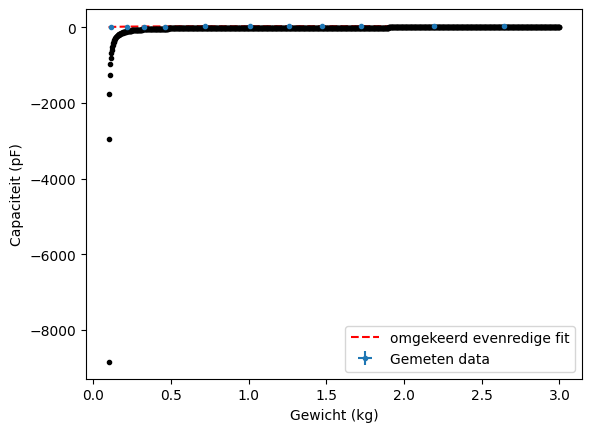

de schatting komt overduidelijk niet overeen met de data


In [10]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

# parameters
R_shunt = 1000 # Ohm
freq = 100000 # Hz
A_in = 8 # V

# data
capaciteitino = np.array([23.1, 20.8, 16.6, 29.3, 32.4, 34.5, 30, 11.9, 12.3, 12.9, 26.8]) # pF
gewicht = np.array([1.0083, 0.7181, 0.4637, 1.7264, 2.1929, 2.641, 1.4748, 0.1127, 0.2164, 0.3291, 1.2627]) # kg
echte_c = capaciteitino * 1e-12

#onzekerheid 
u_gewicht = 0.00005
u_cap = 0.1

#fitten
popt2, pcov2 = curve_fit(cfunctie, gewicht, echte_c)

gewicht_test = np.linspace(0.1, 3, 1000)
cap_test = cfunctie(gewicht_test, *popt2) * 1e12

# plotten
plt.figure()
plt.xlabel('Gewicht (kg)')
plt.ylabel('Capaciteit (pF)')
plt.errorbar(gewicht, capaciteitino, xerr=u_gewicht, yerr=u_cap, fmt='.', label = 'Gemeten data')
plt.plot(gewicht_test, cap_test, 'r--', label = "omgekeerd evenredige fit")
plt.plot(gewicht_test, C_testarray * 1e12, 'k.') 
plt.legend()
plt.show()

print("de schatting komt overduidelijk niet overeen met de data")

## Opdracht 10: Vul hieronder de conclusie in.

De sensor laat duidelijk een verband zien tussen het gewicht op de plaat en de capaciteit, dus de sensor is wel geschikt om als een weegschaal te werken. Bij de fit echter is een groot verschil te zien tussen de voorspelling van de omgekeerd evenredige functie en de uiteindelijk gemeten data. Dit heeft te maken met het feit dat het materiaal steeds meer kracht nodig heeft om verder ingedrukt te worden, en dus geen lineair verband heeft zoals voorspeld. Volgens het fenomeen Youngs Moludus begint het linear en is daarna niet meer te beschrijven als een simpele functie. Onze waarde waren voorbij deze lineare lijn en daarom klopten de natuurkundige afleiding , en dus de fit, niet.  \
We hadden niet genoeg tijd voor iteratie, maar voor verbetering zouden we een ander materiaal gebruiken en de afstand tussen de platen vergroten. \
De vlakke plaat formule kwam beter overeen met de gemeten waardes, maar nog steeds heel slecht. 



## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.
![drie schetsen](synthese_schets.jpeg)
![uitgewerkte schets](sensorschets.jpeg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

![scope meting 1](condensator.jpeg)
![scope meting 2](oscilloscoop.jpeg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.



[ 2.7682721   3.49006169  4.17224504  4.81799502  5.43015441  6.01127776
  6.56366696  7.08940177  7.59036597  8.06826992  8.52467004  8.96098579
  9.37851437  9.77844363 10.16186336 10.52977518 10.88310129 11.22269221
 11.54933357 11.86375222 12.16662162 12.45856661 12.74016781 13.01196536
 13.27446246 13.52812846 13.77340162 14.01069171 14.24038223 14.4628325
 14.67837955 14.88733981 15.09001067 15.28667185 15.47758676 15.66300363
 15.84315658 16.01826664 16.18854263 16.35418199 16.51537158 16.67228831
 16.82509987 16.97396527 17.11903542 17.26045363 17.39835608 17.53287228
 17.66412543 17.79223285 17.91730628 18.03945225 18.15877234 18.2753635
 18.38931829 18.50072514 18.60966854 18.71622933 18.8204848  18.92250898
 19.02237274 19.12014397 19.21588777 19.30966656 19.4015402  19.49156618
 19.57979967 19.66629369 19.75109916 19.83426507 19.91583849 19.99586474
 20.07438742 20.1514485  20.22708843 20.30134616 20.37425922 20.44586382
 20.51619487 20.58528603 20.65316982 20.7198776  20.7

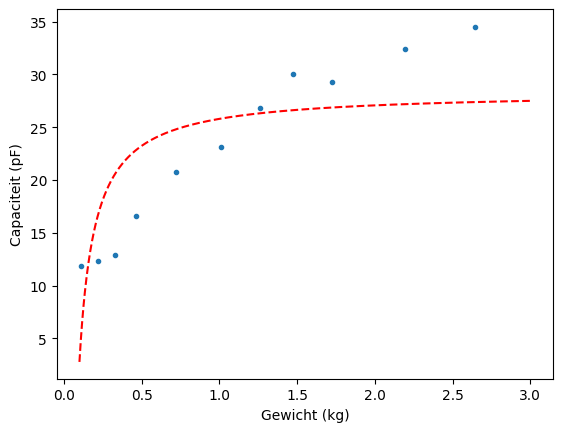

In [11]:
R_shunt = 1000 # Ohm
freq = 100000 # Hz
A_in = 8 # V
capaciteitino = np.array([23.1, 20.8, 16.6, 29.3, 32.4, 34.5, 30, 11.9, 12.3, 12.9, 26.8]) # pF
gewicht = np.array([1.0083, 0.7181, 0.4637, 1.7264, 2.1929, 2.641, 1.4748, 0.1127, 0.2164, 0.3291, 1.2627]) # kg
echte_c = capaciteitino * 1e-12

u_gewicht = 0.00005
u_cap = 0.1

popt2, pcov2 = curve_fit(cfunctie, gewicht, echte_c)

gewicht_test = np.linspace(0.1, 3, 1000)
cap_test = cfunctie(gewicht_test, *popt2) * 1e12
print(cap_test)
plt.figure()
plt.xlabel('Gewicht (kg)')
plt.ylabel('Capaciteit (pF)')
plt.errorbar(gewicht, capaciteitino, xerr=u_gewicht, yerr=u_cap, fmt='.')
plt.plot(gewicht_test, cap_test, 'r--')
plt.show()